# Tugas 5 : Query kalimat dengan cosin & Klasifikasi dengan SVD

In [ ]:
from google.colab import files

# Upload file  dari komputer
uploaded_preprosessing = files.upload()

Saving teks beneran bersih rill cuy.csv to teks beneran bersih rill cuy.csv


In [ ]:
import pandas as pd
import io

# Membaca file CSV yang diunggah dan menyimpannya ke dalam DataFrame dengan variabel df_trans
df = pd.read_csv(io.BytesIO(uploaded_preprosessing['teks beneran bersih rill cuy.csv']))
df.head(5) # Menampilkan 5 baris pertama dari DataFrame

,judul,tanggal,isi,kategori,cleaned_text,norm_text,token_text,swremove_text,clean_text,kategori_encoded
0,Badan Kurus Tak Berarti Bebas dari Kolesterol ...,"Kamis, 05 Sep 2024 11:03 WIB",Jakarta - Tak sedikit yang beranggapan bahwa o...,Kesehatan,Jakarta Tak sedikit yang beranggapan bahwa ora...,jakarta tidak sedikit yang beranggapan bahwa o...,"['jakarta', 'tidak', 'sedikit', 'yang', 'beran...","['jakarta', 'sedikit', 'beranggapan', 'orang',...",jakarta sedikit beranggapan orang berbadan kur...,0
1,Budaya Kerja Toksik di Jepang Picu 54 Karyawan...,"Kamis, 05 Sep 2024 10:38 WIB",Jakarta -\n \n Istilah 'bekerja ...,Kesehatan,Jakarta Istilah bekerja sampai mati nampaknya ...,jakarta istilah bekerja sampai mati nampaknya ...,"['jakarta', 'istilah', 'bekerja', 'sampai', 'm...","['jakarta', 'istilah', 'bekerja', 'mati', 'nam...",jakarta istilah bekerja mati nampaknya ssudah ...,0
2,Menyoal Serangan Jantung yang Dialami Faisal B...,"Kamis, 05 Sep 2024 10:03 WIB",Jakarta - Faisal Basri meninggal dunia. Ekonom...,Kesehatan,Jakarta Faisal Basri meninggal dunia Ekonom Un...,jakarta faisal basri meninggal dunia ekonom un...,"['jakarta', 'faisal', 'basri', 'meninggal', 'd...","['jakarta', 'faisal', 'basri', 'meninggal', 'd...",jakarta faisal basri meninggal dunia ekonom un...,0
3,Nyeri Kronis yang Bikin Paus Fransiskus Tak Bi...,"Kamis, 05 Sep 2024 09:37 WIB",Jakarta - Pemimpin tertinggi Gereja Katolik se...,Kesehatan,Jakarta Pemimpin tertinggi Gereja Katolik sedu...,jakarta pemimpin tertinggi gereja katolik sedu...,"['jakarta', 'pemimpin', 'tertinggi', 'gereja',...","['jakarta', 'pemimpin', 'tertinggi', 'gereja',...",jakarta pemimpin tertinggi gereja katolik sedu...,0
4,"Perundungan PPDS Tak Cuma Terjadi di Undip, Be...","Kamis, 05 Sep 2024 08:35 WIB",Jakarta - Aksi bullying atau perundungan di ma...,Kesehatan,Jakarta Aksi bullying atau perundungan di masa...,jakarta aksi bullying atau perundungan di masa...,"['jakarta', 'aksi', 'bullying', 'atau', 'perun...","['jakarta', 'aksi', 'bullying', 'perundungan',...",jakarta aksi bullying perundungan masa program...,0


In [ ]:
# 2. Preprocessing sederhana (contoh: lowercasing)
berita_preprocessed = [kalimat.lower() for kalimat in clean_text]

In [ ]:
# 3. TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(berita_preprocessed)

# Mendapatkan fitur (kata-kata) dari TF-IDF
tfidf_features = tfidf_vectorizer.get_feature_names_out()

# Mengonversi matriks TF-IDF menjadi DataFrame agar lebih mudah dibaca
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_features)

# Tampilkan hasil TF-IDF
print("\nHasil TF-IDF dalam bentuk DataFrame:")
print(tfidf_df)



Hasil TF-IDF dalam bentuk DataFrame:
    000   10   15   19  195   20  2024  2025  211   24  ...  waktu  wanita  \
0   0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  ...    0.0     0.0   
1   0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  ...    0.0     0.0   
2   0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  ...    0.0     0.0   
3   0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  ...    0.0     0.0   
4   0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  ...    0.0     0.0   
..  ...  ...  ...  ...  ...  ...   ...   ...  ...  ...  ...    ...     ...   
95  0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  ...    0.0     0.0   
96  0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  ...    0.0     0.0   
97  0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  ...    0.0     0.0   
98  0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  ...    0.0     0.0   
99  0.0  0.0  0.0  0.0  0.0  0.0   0.0   0.0  0.0  0.0  ...    0.0     0.0   

    warga  waspadai  west

Hasil reduksi dimensi dengan SVD:
   Component 1  Component 2  Component 3  Component 4  Component 5  \
0     0.213752     0.036683    -0.204686     0.389656    -0.080721   
1     0.095339    -0.051426    -0.029600     0.035798    -0.018530   
2     0.042067     0.012982    -0.025553     0.030792     0.018403   
3     0.191291    -0.073104    -0.123250     0.032401     0.314551   
4     0.314895    -0.018816    -0.110984    -0.126921    -0.091162   

   Component 6  Component 7  Component 8  Component 9  Component 10  
0     0.078165    -0.015633    -0.014630     0.057005     -0.170401  
1     0.056618     0.221770     0.152433     0.001675      0.134562  
2    -0.030063    -0.029431     0.047575    -0.024371      0.057923  
3    -0.018575    -0.089987     0.137856    -0.050332     -0.044651  
4     0.381451    -0.248668     0.007507    -0.151577      0.114529  


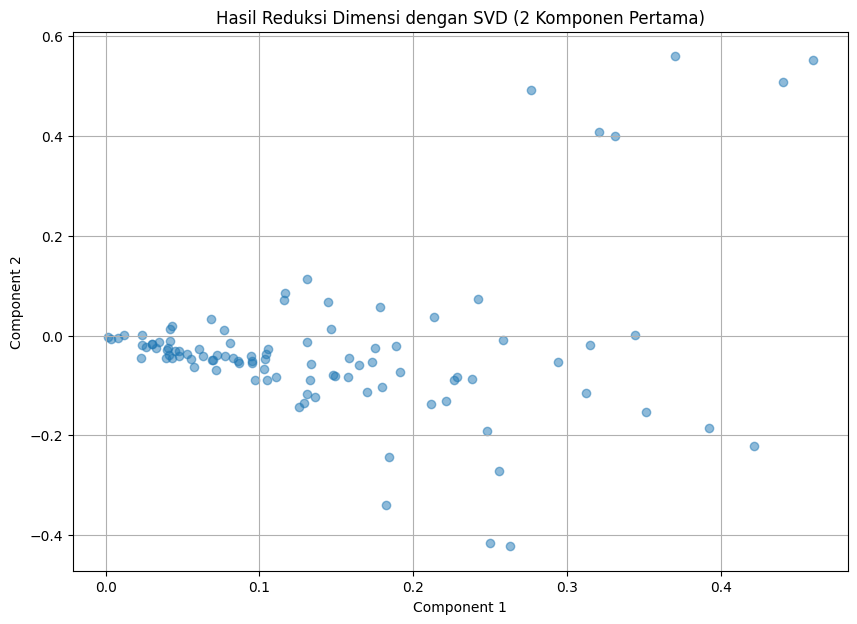

In [ ]:
# Menggunakan SVD untuk reduksi dimensi
n_components = 10  # Jumlah komponen yang ingin digunakan
svd = TruncatedSVD(n_components=n_components)
svd_matrix = svd.fit_transform(tfidf_matrix)

# Mengubah hasil SVD menjadi DataFrame untuk kemudahan
svd_df = pd.DataFrame(svd_matrix, columns=[f'Component {i+1}' for i in range(n_components)])

# Menampilkan hasil
print("Hasil reduksi dimensi dengan SVD:")
print(svd_df.head())  # Menampilkan 5 baris pertama dari hasil SVD

# Visualisasi hasil untuk 2 komponen pertama
plt.figure(figsize=(10, 7))
plt.scatter(svd_df['Component 1'], svd_df['Component 2'], alpha=0.5)
plt.title('Hasil Reduksi Dimensi dengan SVD (2 Komponen Pertama)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid()
plt.show()

In [ ]:
import re

# Kalimat query
query = """jakarta sedikit beranggapan orang berbadan kurus bebas risiko kolesterol tinggi dibandingkan orang berbadan gemuk ssudah punya kolesterol tinggi sebenarnya anggapan tersebut benar adanyaspesialis penyakit dr aru ariadno sppdkgeh menjelaskan pernyataan tersebut sepenuhnya tepat mengatidakan sebenarnya banyak faktor membuat kadar kolesterol tubuh seseorang naik pola makan buruk kurangnya olahraga memang menjadi faktor utama kolesterol tinggi faktor seperti genetik seseorang berpengaruh advertisement scroll to continue with content kolesterol hubungannya genetik orang kurus mengalami gangguan kolesterol kata dr aru dihubungi detikcom rabu orang memiliki badan gemuk obesitas memang lebih rentan masalah kolesterol tinggi hanya hipertensi masalah obesitas bisa berdampak kesehatan manusia umum ditangani baik baca sederet gejala kolesterol tinggi bisa muncul priaselain berat badan berlebih kerap dikaitkan pola makan tinggi lemak kurangnya aktivitas fisik mana semakin memperbesar risiko tingginya kolesterol darahketika seseorang mengalami obese bisa menyebabkan sindrom metabolik termasuk diabetes kolesterol tinggi hipertensi ujarnya dr aru mengingatkan kolesterol tinggi paling banyak diakibatkan pola makan buruk jarang berolahraga ini berpengaruh pada semua orang tidak melihat orang tersebut memiliki badan kurus gemuk menurutnya pola hidup sehat menjadi kunci utama pengelolaan kadar kolesterol tubuh jangan lupa menjaga tingkat stres berhenti merokok untuk membantu mencegah masalah kolesterol timbul baca juga sering sakit bagian belakang kepala bisa jadi tanda kolesterol tinggi dokter spesialis saraf stroke bisa dicegah dokter spesialis saraf stroke bisa dicegah avksuc kolesterol tinggi badan kurus gaya hidup sehat sindrom metabolik"""

# Preprocessing: menghapus karakter yang tidak perlu dan merapikan spasi
query_preprocessed = re.sub(r'\s+', ' ', query)  # Menghapus spasi berlebih
query_preprocessed = query_preprocessed.strip()  # Menghapus spasi di awal dan akhir
query_preprocessed = re.sub(r'\n+', ' ', query_preprocessed)  # Menghapus newline
query_preprocessed = re.sub(r'-+', '-', query_preprocessed)  # Mengganti banyak dash menjadi satu

# Mengubah ke huruf kecil
query_preprocessed = query_preprocessed.lower()

# Menampilkan hasil
print("Berita yang sudah dirapikan:")
print(query_preprocessed)


Berita yang sudah dirapikan:
jakarta sedikit beranggapan orang berbadan kurus bebas risiko kolesterol tinggi dibandingkan orang berbadan gemuk ssudah punya kolesterol tinggi sebenarnya anggapan tersebut benar adanyaspesialis penyakit dr aru ariadno sppdkgeh menjelaskan pernyataan tersebut sepenuhnya tepat mengatidakan sebenarnya banyak faktor membuat kadar kolesterol tubuh seseorang naik pola makan buruk kurangnya olahraga memang menjadi faktor utama kolesterol tinggi faktor seperti genetik seseorang berpengaruh advertisement scroll to continue with content kolesterol hubungannya genetik orang kurus mengalami gangguan kolesterol kata dr aru dihubungi detikcom rabu orang memiliki badan gemuk obesitas memang lebih rentan masalah kolesterol tinggi hanya hipertensi masalah obesitas bisa berdampak kesehatan manusia umum ditangani baik baca sederet gejala kolesterol tinggi bisa muncul priaselain berat badan berlebih kerap dikaitkan pola makan tinggi lemak kurangnya aktivitas fisik mana semak

In [ ]:
# Transformasi query ke bentuk TF-IDF
query_tfidf = tfidf_vectorizer.transform([query_preprocessed])

# Transformasi TF-IDF ke SVD
query_svd = svd.transform(query_tfidf)

# Mengubah hasil query SVD menjadi DataFrame untuk kemudahan
query_svd_df = pd.DataFrame(query_svd, columns=[f'Component {i+1}' for i in range(n_components)])
# Menampilkan hasil
print("Hasil transformasi query ke SVD:")
print(query_svd_df)

Hasil transformasi query ke SVD:
   Component 1  Component 2  Component 3  Component 4  Component 5  \
0     0.262788    -0.031313     -0.35015     0.452574    -0.127445   

   Component 6  Component 7  Component 8  Component 9  Component 10  
0    -0.107523    -0.037133    -0.032511     -0.01166     -0.063604  


In [ ]:
# Menghitung cosine similarity antara query dan setiap berita
similarity_scores = cosine_similarity(query_svd, svd_matrix)

# Menampilkan nilai cosine similarity
print("Nilai Cosine Similarity antara query dan setiap berita:")
print(similarity_scores)

Nilai Cosine Similarity antara query dan setiap berita:
[[ 0.89935144  0.12843931  0.4270554   0.26095224  0.09589732  0.90375271
   0.02749225  0.49090884 -0.05900043  0.16533649  0.10103029  0.96676335
   0.40010458 -0.06823398 -0.10275538  0.02527853  0.90659509 -0.02366122
   0.14287907 -0.05161356  0.25121651  0.0276631   0.13011463  0.0708967
   0.20776728  0.85440264 -0.08253955 -0.06018988  0.82062638  0.07959411
   0.617996    0.07410941  0.1863487   0.20506005  0.88058944  0.12655091
  -0.05725128  0.37089799  0.94101116  0.03583772 -0.08903423  0.28063099
  -0.04971093 -0.00267604  0.09347125  0.51931299 -0.00221469 -0.04056293
   0.21812045  0.37382671 -0.01503043  0.11685036 -0.06388233  0.34527202
   0.09249881  0.02615472  0.11872543 -0.08240457 -0.16845503 -0.18611692
   0.12958193  0.13752858  0.04465545 -0.11398146 -0.04438481  0.21733542
   0.00623215  0.03378109  0.00173349 -0.05232745  0.00202712  0.22395498
  -0.01535142 -0.09005216  0.23543712  0.08891314  0.2114

In [ ]:
# Mengurutkan indeks berdasarkan skor similarity (descending)
most_relevant_indices = np.argsort(similarity_scores[0])[::-1]

# Memastikan indeks tidak melebihi panjang list berita
num_top_results = 5
top_5_relevant_berita = [(i, clean_text[i], similarity_scores[0][i]) for i in most_relevant_indices[:num_top_results] if i < len(clean_text)]

# Cetak hasil dengan nilai cosine similarity
print("\nBerita yang paling relevan dengan query beserta nilai cosine similarity:")
for idx, (original_index, berita_text, similarity) in enumerate(top_5_relevant_berita, 1):
    # Hanya menampilkan teks berita tanpa karakter yang tidak diinginkan
    cleaned_text = berita_text.replace("r", "").replace("s", "").replace("a", "").replace("t", "").strip()
    print(f"{idx}. (Nomor Asli: {original_index + 1}) {cleaned_text} - Cosine Similarity: {similarity:.4f}")


Berita yang paling relevan dengan query beserta nilai cosine similarity:
1. (Nomor Asli: 12) Sedee Gejl Koleeol Tinggi yng Bi Muncul pd Pi - Cosine Similarity: 0.9668
2. (Nomor Asli: 39) Tnd Koleeol Tinggi Jug Bi Muncul di M, Wpdi Cii-ciiny - Cosine Similarity: 0.9410
3. (Nomor Asli: 17) Seing Ski di Bgin Belkng Kepl? Bi Jdi Tnd Koleeol Tinggi - Cosine Similarity: 0.9066
4. (Nomor Asli: 6) Doke Ungkp 'Bing Keok' Koleeol Tinggi di Ui Mud, Teny geg Ini - Cosine Similarity: 0.9038
5. (Nomor Asli: 1) Bdn Kuu Tk Bei Beb di Koleeol Tinggi, Doke Ungkp Fkny - Cosine Similarity: 0.8994


# Pencarian kalimat dengan Euclidean distance

In [ ]:
from google.colab import files

# Upload file  dari komputer
uploaded_preprosessing = files.upload()

Saving teks beneran bersih rill cuy.csv to teks beneran bersih rill cuy.csv


In [ ]:
import pandas as pd
import io

# Membaca file CSV yang diunggah dan menyimpannya ke dalam DataFrame dengan variabel df_trans
df = pd.read_csv(io.BytesIO(uploaded_preprosessing['teks beneran bersih rill cuy.csv']))
df.head(5) # Menampilkan 5 baris pertama dari DataFrame

,judul,tanggal,isi,kategori,cleaned_text,norm_text,token_text,swremove_text,clean_text,kategori_encoded
0,Badan Kurus Tak Berarti Bebas dari Kolesterol ...,"Kamis, 05 Sep 2024 11:03 WIB",Jakarta - Tak sedikit yang beranggapan bahwa o...,Kesehatan,Jakarta Tak sedikit yang beranggapan bahwa ora...,jakarta tidak sedikit yang beranggapan bahwa o...,"['jakarta', 'tidak', 'sedikit', 'yang', 'beran...","['jakarta', 'sedikit', 'beranggapan', 'orang',...",jakarta sedikit beranggapan orang berbadan kur...,0
1,Budaya Kerja Toksik di Jepang Picu 54 Karyawan...,"Kamis, 05 Sep 2024 10:38 WIB",Jakarta -\n \n Istilah 'bekerja ...,Kesehatan,Jakarta Istilah bekerja sampai mati nampaknya ...,jakarta istilah bekerja sampai mati nampaknya ...,"['jakarta', 'istilah', 'bekerja', 'sampai', 'm...","['jakarta', 'istilah', 'bekerja', 'mati', 'nam...",jakarta istilah bekerja mati nampaknya ssudah ...,0
2,Menyoal Serangan Jantung yang Dialami Faisal B...,"Kamis, 05 Sep 2024 10:03 WIB",Jakarta - Faisal Basri meninggal dunia. Ekonom...,Kesehatan,Jakarta Faisal Basri meninggal dunia Ekonom Un...,jakarta faisal basri meninggal dunia ekonom un...,"['jakarta', 'faisal', 'basri', 'meninggal', 'd...","['jakarta', 'faisal', 'basri', 'meninggal', 'd...",jakarta faisal basri meninggal dunia ekonom un...,0
3,Nyeri Kronis yang Bikin Paus Fransiskus Tak Bi...,"Kamis, 05 Sep 2024 09:37 WIB",Jakarta - Pemimpin tertinggi Gereja Katolik se...,Kesehatan,Jakarta Pemimpin tertinggi Gereja Katolik sedu...,jakarta pemimpin tertinggi gereja katolik sedu...,"['jakarta', 'pemimpin', 'tertinggi', 'gereja',...","['jakarta', 'pemimpin', 'tertinggi', 'gereja',...",jakarta pemimpin tertinggi gereja katolik sedu...,0
4,"Perundungan PPDS Tak Cuma Terjadi di Undip, Be...","Kamis, 05 Sep 2024 08:35 WIB",Jakarta - Aksi bullying atau perundungan di ma...,Kesehatan,Jakarta Aksi bullying atau perundungan di masa...,jakarta aksi bullying atau perundungan di masa...,"['jakarta', 'aksi', 'bullying', 'atau', 'perun...","['jakarta', 'aksi', 'bullying', 'perundungan',...",jakarta aksi bullying perundungan masa program...,0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Memisahkan fitur dan label
x = df['clean_text']
y = df['kategori_encoded']

In [ ]:
# Membagi data menjadi data latih dan data uji
X_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

**TF-IDF (Term Frequency-Inverse Document Frequency)**

In [ ]:
# Tahap 1: TF-IDF
tfidf_vectorizer = TfidfVectorizer()
x_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

# Mengonversi hasil TF-IDF menjadi DataFrame
df_train_tfidf = pd.DataFrame(x_train_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
df_test_tfidf = pd.DataFrame(x_test_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print("Hasil TF-IDF (Data Latih):")
df_train_tfidf

Hasil TF-IDF (Data Latih):


,aachen,abad,abang,abc,abdalmasih,abinader,absen,abuabu,ac,academic,...,yunita,yura,zaman,zat,zealand,zef,zenix,zero,zulies,zurich
0,0.0,0.0,0.000000,0.0,0.096079,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
76,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
77,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
78,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


**Singular Value Decomposition (SVD)**

In [ ]:
# Tahap 2: SVD (Reduksi Dimensi)
svd = TruncatedSVD(n_components=100, random_state=42)
x_train_svd = svd.fit_transform(x_train_tfidf)
x_test_svd = svd.transform(x_test_tfidf)

# Mengonversi hasil SVD menjadi DataFrame
df_train_svd = pd.DataFrame(x_train_svd)
df_test_svd = pd.DataFrame(x_test_svd)
print("\nHasil SVD (Data Latih):")
df_train_svd


Hasil SVD (Data Latih):


,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,0.224455,-0.103978,-0.030172,0.023534,0.264635,-0.147727,-0.008347,0.005567,0.041020,0.005741,...,0.004318,0.010252,-0.008429,-0.001550,-0.009286,-0.007346,0.009390,-0.000642,-0.001747,-0.005317
1,0.129928,-0.034434,-0.033263,0.033561,0.120673,0.069598,-0.023106,0.069306,0.731014,-0.385649,...,-0.095049,-0.050506,0.029296,0.023704,0.011568,0.000981,0.006979,-0.004385,0.001967,-0.000243
2,0.236166,0.010327,-0.016777,0.005285,0.163556,0.422435,-0.169527,-0.167971,-0.095192,-0.091274,...,0.012310,0.021813,-0.019696,0.004342,0.011807,-0.019058,0.000884,0.001221,-0.000908,-0.001858
3,0.274914,0.005290,-0.003888,0.027130,0.226023,0.537075,-0.138059,-0.150584,-0.136672,-0.112361,...,-0.031744,-0.042743,-0.009592,0.007783,0.014781,0.024714,-0.040165,0.003853,0.006993,-0.005433
4,0.162625,-0.031245,0.029551,-0.027121,0.029687,0.049772,0.004012,0.282602,0.018042,0.116029,...,0.018898,0.028325,0.000478,0.005624,-0.008813,-0.005923,-0.007392,0.002264,0.003268,-0.000419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.113703,-0.028407,-0.011338,0.005204,0.027898,0.037545,-0.014502,0.101277,0.083787,0.135065,...,0.001469,0.005038,-0.007172,0.002141,0.006904,0.001287,-0.008522,-0.000311,0.004106,-0.010123
76,0.163339,-0.043736,-0.031690,0.020323,0.054186,0.052664,-0.009302,0.077485,0.208262,0.184481,...,0.000599,-0.012445,-0.017145,0.000073,0.001176,0.001192,0.003302,0.002784,-0.000389,-0.004143
77,0.119302,0.034540,0.002866,0.017624,0.041137,0.075067,0.061471,0.010764,0.016659,0.105149,...,0.001630,0.002618,-0.017211,0.003081,-0.000008,0.007591,0.006627,0.000188,-0.000136,-0.000333
78,0.111802,-0.018992,-0.012303,0.032514,0.059399,0.083362,-0.025351,0.111499,0.111294,0.451354,...,-0.002846,-0.008684,-0.016636,0.008218,0.007914,-0.004514,-0.006289,0.003743,0.000940,0.001600


# Modeling

In [ ]:
# Tahap 3: Klasifikasi dengan Logistic Regression
clf = LogisticRegression(C=0.2, random_state=42)
clf.fit(x_train_svd, y_train)
y_pred = clf.predict(x_test_svd)

# Evaluasi

In [ ]:
# Evaluasi Model
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.80      1.00      0.89         8

    accuracy                           0.90        20
   macro avg       0.90      0.92      0.90        20
weighted avg       0.92      0.90      0.90        20



Pengujian

---



In [ ]:
import joblib
from sklearn.pipeline import Pipeline

# Misalnya, Anda telah membuat pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('x_train_svd', TruncatedSVD(n_components=100)),
    ('clf', LogisticRegression())
])

# Fit pada data pelatihan
pipeline.fit(X_train, y_train)

# Menyimpan pipeline
joblib.dump(pipeline, 'svd_tfidf_pipeline.pkl')

['svd_tfidf_pipeline.pkl']

In [ ]:
import joblib
import pandas as pd

# Memuat pipeline yang telah disimpan
pipeline = joblib.load('svd_tfidf_pipeline.pkl')

# Teks baru yang ingin diprediksi
new_text_1 = ['''jakarta sedikit beranggapan orang berbadan kurus bebas risiko kolesterol tinggi dibandingkan orang berbadan gemuk ssudah punya kolesterol tinggi sebenarnya anggapan tersebut benar adanyaspesialis penyakit dr aru ariadno sppdkgeh menjelaskan pernyataan tersebut sepenuhnya tepat mengatidakan sebenarnya banyak faktor membuat kadar kolesterol tubuh seseorang naik pola makan buruk kurangnya olahraga memang menjadi faktor utama kolesterol tinggi faktor seperti genetik seseorang berpengaruh advertisement scroll to continue with content kolesterol hubungannya genetik orang kurus mengalami gangguan kolesterol kata dr aru dihubungi detikcom rabu orang memiliki badan gemuk obesitas memang lebih rentan masalah kolesterol tinggi hanya hipertensi masalah obesitas bisa berdampak kesehatan manusia umum ditangani baik baca sederet gejala kolesterol tinggi bisa muncul priaselain berat badan berlebih kerap dikaitkan pola makan tinggi lemak kurangnya aktivitas fisik mana semakin memperbesar risiko tingginya kolesterol darahketika seseorang mengalami obese bisa menyebabkan sindrom metabolik termasuk diabetes kolesterol tinggi hipertensi ujarnya dr aru mengingatkan kolesterol tinggi paling banyak diakibatkan pola makan buruk jarang berolahraga ini berpengaruh pada semua orang tidak melihat orang tersebut memiliki badan kurus gemuk menurutnya pola hidup sehat menjadi kunci utama pengelolaan kadar kolesterol tubuh jangan lupa menjaga tingkat stres berhenti merokok untuk membantu mencegah masalah kolesterol timbul baca juga sering sakit bagian belakang kepala bisa jadi tanda kolesterol tinggi dokter spesialis saraf stroke bisa dicegah dokter spesialis saraf stroke bisa dicegah avksuc kolesterol tinggi badan kurus gaya hidup sehat sindrom metabolik''']

new_text_2 = ['''jakarta pemimpin tertinggi gereja katolik sedunia paus fransiskus mau bermewahmewah berkunjung indonesia mobilnya cuma innova menginap kedubes vatikan paus fransiskus terbang bandara internasional leonardo da vinci roma fiumicino senin tiba bandara soekarno hatta cengkareng sehari kemudian selasa menggunakan pesawat komersil italia ita airways paus menginap kedutaan besar vatikan bukan hotel selama jakarta wirawiri jakarta jenis mobil digunakan paus toyota innova zenix pindad maung mv ssudah dimodifikasi khusus advertisement scroll to continue with content menteri koordinator bidang kemaritiman investasi menko marves luhut binsar pandjaitan mengomentari soal pilihan paus fransiskus enggan bermewahmewah luhut mengatidakan pemerintah menuruti keinginan paus fransiskus memakai akomodasi transportasi sederhana advertisement beliau maunya turutin kata luhut singkat bali international convention center nusa badung bali selasa baca geiranger indah jadi saksi pernikahan putri norwegia dukunluhut menyebut pemerintah indonesia ssudah menyediakan akomodasi transportasi terbaik keamanan tingkat tinggi setiap kepala negara berkunjung indonesia pelayanan berlaku paus fransiskus semua akomodasi transportasi mewah disediakan pemerintah tamu negara ditolak memang permintaan khusus tamu negara bersangkutankalau maunya itu kami berikan semuanya kata luhut baca desa kallio tenggelam muncul danau mornos kekeringanluhut sekaligus mengapresiasi kedatangan paus fransiskus indonesia menurutnya kedatangan paus fransiskus makin melegitimasi nama indonesia makin melambung kancah internasional tahun lalu paus datang indonesia nah sekarang beliau datang sini katanya paus berada jakarta selama tiga hari september kedatangan paus bernama asli jorge bergoglio itu indonesia melakukan perjalanan apostolik baca pungutan turis asing bali terkumpul rp m buat apaselama indonesia paus dijadwalkan berkunjung sejumlah tempat lain istana merdeka grha pemuda masjid istiqlal kantor konferensi waligereja indonesia kwi hingga gelora bung karno gbksetelah jakarta kunjungan paus fransiskus berlanjut papua nugini kemudian timor leste singapura berita terpopuler detiktravel rabu kemarin itu ada berita terpopuler lainnya fotofoto terbaru titanic makin hancur hingga kecewanya turis malaysia berdiri jam antre imigrasi bandara komodo labuan bajo berikut berita terpopuler detiktravel rabu luhut soal penginapan mobil untuk paus tidak mewah jakarta wow super air jet buka rute baru semarang apa simak harimau serang pawang insiden paling langka terjadi fotofoto baru bangkai titanic semakin rusak rontok rute dieng jakarta naik kereta api beserta waktu tempuhnya ogah bayar layanan turis palestina keroyok staf hotel tewas saat rombongan paus fransiskus kira bangunan tanah abang istiqlal belasan gedung china dihancurkan ternyata proyek ambisius kehabisan uang coba tebak pulau cantik terletidak di mana turis malaysia kecewa jam berdiri antre imigrasi di bandara komodo potret kesederhanaan paus fransiskus kunjungan indonesia potret kesederhanaan paus fransiskus kunjungan ke indonesia wswwsw berita terpopuler detiktravel paus fransiskus luhut binsar pandjaitan turis malaysia''']

# Gabungkan kedua teks menjadi satu list
new_text = new_text_1 + new_text_2


# Melakukan prediksi dengan pipeline
predictions = pipeline.predict(new_text)

# Hasil prediksi
predicted_categories = ["Kesehatan" if predictions ==  0 else "pariwisata" for predictions in predictions]

# Output hasil prediksi untuk masing-masing teks
for i, category in enumerate(predicted_categories):
    print(f"Prediksi untuk teks {i+1}: {category}")

Prediksi untuk teks 1: Kesehatan
Prediksi untuk teks 2: pariwisata
